In [31]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

In [33]:
# Load data
df = pd.read_csv("/content/processed_data.csv")

In [34]:
# Encode categorical
le = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [35]:
display(X.head())

,uid,MeSH,Problems,image,indication,comparison,findings,impression,filename
0,1,1806,1354,673,676,213,1364,1255,1058
1,2,438,421,332,702,213,44,1174,2095
2,3,1806,1354,673,2317,383,2440,1194,3175
3,4,1596,1184,562,1352,206,2180,20,3283
4,5,1492,1106,673,176,383,1425,1090,3386


In [36]:
# Split
X = df.drop("projection", axis=1)
y = df["projection"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [37]:
# Model comparison
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

In [42]:
print(df['projection'].unique())

[0]


In [43]:
# Final model
model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [44]:
# Accuracy
print("Final Accuracy:", accuracy_score(y_test, pred))

Final Accuracy: 1.0


In [45]:
import os
import matplotlib.pyplot as plt

# Define the output directory
output_dir = "/content/outputs"
plot_output_dir = os.path.join(output_dir, "plots")

# Create the directories if they don't exist
os.makedirs(output_dir, exist_ok=True)
os.makedirs(plot_output_dir, exist_ok=True)

# Save model
joblib.dump(model, os.path.join(output_dir, "model.pkl"))

['/content/outputs/model.pkl']

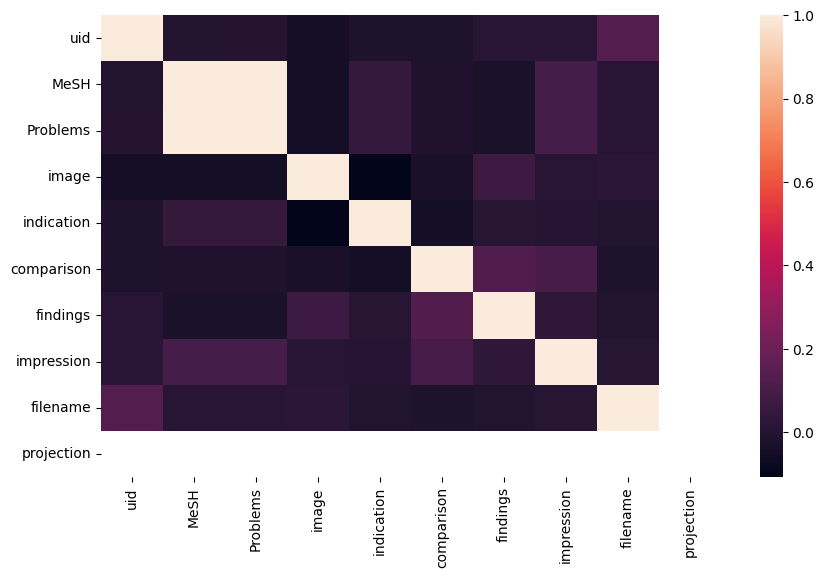

In [40]:
# Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=False)
plt.savefig(os.path.join(plot_output_dir, "heatmap.png"))
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


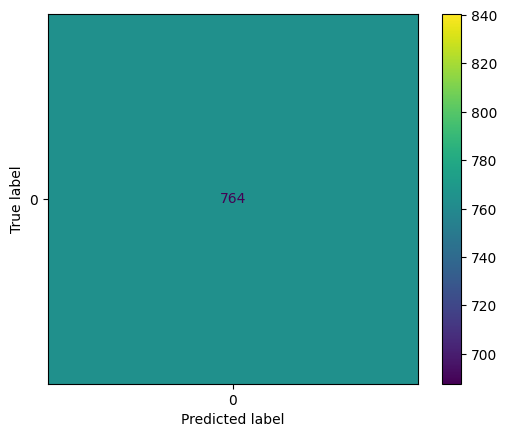

In [47]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.savefig(os.path.join(plot_output_dir, "confusion_matrix.png"))
plt.show()